# Hamiltonian Simulation using Trotterization

In [ ]:
!pip install qiskit > /dev/null
!pip install qiskit_aer > /dev/null
!pip install qiskit_ibm_runtime > /dev/null
!pip install qbraid-core > /dev/null

In [ ]:
!pip install pylatexenc > /dev/null
!pip install sympy > /dev/null

## Exercise 3: Hamiltonian Simulation of the Transverse-Field Ising Hamiltonian

1. As the transverse-field Ising Hamiltonian is already specified in terms of two types of Pauli strings only, for simplicity, you can directly implement a function that only takes as input the parameters $J,h$ of  (as opposed to additionally providing the Pauli strings as input) and outputs the trotterized Hamiltonian simulation circuit.


    Write a function that takes as input:
    - the number $n$ of spins (qubits) for the Hamiltonian
    - an $n$-qubit QuantumCircuit object (this circuit encodes your input state)
    - the parameters $J$, $h$ for the transverse-field Ising Hamiltonian
    - the number of Trotter steps $r$
    - the evolution time $t$
        
    and appends to the input QuantumCircuit the circuit corresponding to the trotterized Hamiltonian simulation of  the transverse-field Ising Hamiltonian. Use only basic Qiskit operations and features such as those you have seen in the exercise sheets, i.e. build the circuit by applying gates (only CNOT, Hadamard and rotation gates) to a quantum circuit. 

**You are NOT allowed to use Qiskit's built-in operations for Hamiltonians/Trotterization**

In [8]:
from qiskit import QuantumCircuit

# Recall: the Trotter formula for e^(A+B) allows us to approximate this exponential as (e^(A/r) * e^(B/r))^r.
# We express the Ising Hamiltonian approximation:
# e^(-i * H_Ising * t) = e^(-i * (-J*(sum_i Z_i Z_i+1) -h*(sum_i X_i)) * t)
# This splits neatly into e^(i*(Jt/r)*(sum_i Z_i Z_i+1)) * e^(i*(ht/r)*(sum_i X_i)); this is what we implement.

def apply_ZZ_exp(circ, n, i, J, t, r):
    """
    Small helper that applies exp(-i*theta*(Z tensor Z)), for the value of theta = Jt/r,
    onto n-qubit quantum circuit circ.
    Note that the parameter i is not the imaginary unit used in the exponential, but rather an index.
    (See Part 1, Ex. 1.6)
    """
    circ.cx(i, (i+1) % n)
    circ.rz(-2*J*t/r, (i+1) % n) # the "separated" Ising Hamiltonian has positive exponents, but the rotations have negative ones
    circ.cx(i, (i+1) % n)

def trotterized_Ising(n,J,h,qc,r,t):

    """
    Appends to input circuit qc a circuit for trotterized Hamiltonian simulation of the transverse-field Ising Hamiltonian 
    with periodic boundary condition. 
    
    input: 
    - int n: number of qubits of Hamiltonian
    - floats J,h: parameters for transverse-field Ising Hamiltonian
    - QuantumCircuit qc: quantum circuit 
    - int r: number of Trotter steps
    - float t: Hamiltonian evolution time 
    """
    for rr in range(r):
        for i in range(0,n):
            apply_ZZ_exp(qc, n, i, J, t, r)
            # Recall: e^(-i * theta * X_i) = R_X_i(theta) (see Ex 2.2 (b))
            qc.rx(-2*h*t/r, i)
    

3. Using the method you proposed in the previous exercise, compare the circuit you obtain with your
_trotterized_Ising_ function to Qiskit's built-in implementation of exact evolution (using the code provided below) for parameters $n = 4$, $t = 5$, $h=J=1$ and $r \in \{1,2,5,10,50\}$. What do you expect to see given the theoretical error bound (Equation 2)? Do your results match your expectation?

    
    _Hint: You can (but don't have to) use the following lines to obtain the unitary associated to a given QuantumCircuit object_ qc:  

    from qiskit.quantum_info import Operator  
    U = Operator(qc).data
    
    _Another potentially useful function is the_ .inverse() _method which returns the inverse of a given quantum circuit and would be used as_:
   
    qc_inv = qc.inverse()

In [9]:
from qiskit.circuit.library import HamiltonianGate
from qiskit.quantum_info import SparsePauliOp
from qiskit.quantum_info import Operator
import numpy as np
import matplotlib.pyplot as plt


# parameters used for comparison

n = 4
J = 1
h = 1
t = 5
r_values = [1,2,5,10,50,100]


# construct Hamiltonian (don't modify anything here!)
ZZ_tuples = [("ZZ", [i, i + 1], -J) for i in range(0, n - 1)] + [("ZZ",[n-1,0],-J)]
X_tuples = [("X", [i], -h) for i in range(0, n)]
hamiltonian = SparsePauliOp.from_sparse_list([*ZZ_tuples, *X_tuples], num_qubits=n)
H = hamiltonian.simplify()
H_matrix = H.to_matrix()


# array for comparison benchmark as function of Trotter steps r
approx_error_r = []

for r in r_values: 
    
     # obtain quantum circuit for trotterized evolution, initial state = all zeros
    qc_trotter = QuantumCircuit(n)
    trotterized_Ising(n,J,h,qc_trotter,r,t)
    
    # calculate exact evolution for time t
    qc_exact = QuantumCircuit(n)
    exact_evolution = HamiltonianGate(H_matrix, time=t)
    qc_exact.append(exact_evolution,range(n))
    
    my_circuit_unitary = Operator(qc_trotter).data
    qiskit_circuit_unitary = Operator(qc_exact).data
    approx_error = np.linalg.norm(qiskit_circuit_unitary - my_circuit_unitary, ord=2)
    
    approx_error_r.append(approx_error)

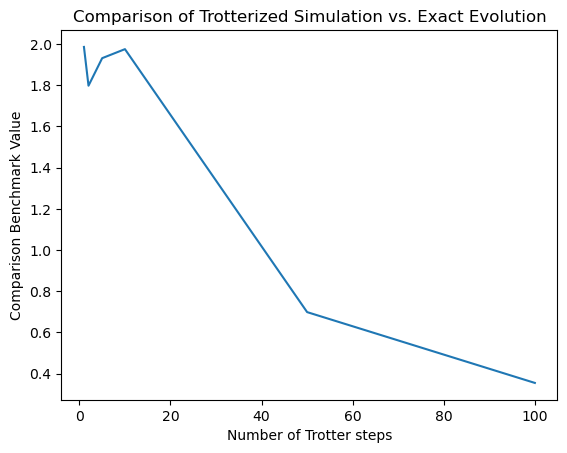

In [7]:
# plot results

plt.plot(r_values,approx_error_r)
plt.title("Comparison of Trotterized Simulation vs. Exact Evolution")
plt.xlabel("Number of Trotter steps")
plt.ylabel("Comparison Benchmark Value")
plt.show()

4.  Fix system size $n = 4$, $J = 1$ and total evolution time $T = 5$.

For each transverse field strength $h \in \{0.2,\;1,\;2\}$ do the following:


(a) For each Trotter step number  

  $r \in \{1,\;2,\;5,\;50\}$, 
  simulate the evolution
  $
  \ket{\psi_t} = e^{-iHt}\ket{0^n}
  $
  using a Trotterized circuit, for $t_{step} = 50$ time steps.

  At each time step, estimate (with 4000 shots) the empirical probability distribution of measuring the output of the circuit, and save it (in a dictionary). 

In [10]:
from qiskit_aer import AerSimulator
import numpy as np

backend = AerSimulator()


# problem parameters
n = 4
T = 5
t_steps = 50
J = 1
num_shots = 4000
h_values = [0.2,1,2]
r_values = [1,2,5,10,50]
times = np.linspace(0, T, t_steps)

#dictionary in which to save results for different tuples (h,r)
counts_results = {}

for h in h_values: 
    for r in r_values:
        counts = []
        for t in times:
            
            qcirc = QuantumCircuit(n)
            trotterized_Ising(n, J, h, qcirc, r, t)
            qcirc.measure_all()
            job = backend.run(qcirc, backend=backend, shots=num_shots, optimization_level=3)
            result = job.result()
            counts_t = result.get_counts(qcirc)
            
            counts.append(counts_t)
        counts_results[(h,r)] = counts

(b) Denote by $p_0(t)$ the (empirical) probability to measure the all-zeros state at time $t$ of the simulation.

Implement a function get_p0(counts,num_shots) that takes as input a counts dictionary (from measuring the output of a circuit num_shots times) and the corresponding number of shots num_shots and outputs the empirical probability of the all-zeros outcome (i.e. the number of counts of the all-zeros outcome divided by the total number of shots). 

In [11]:
import json

all_zeros_key = "0" * n

# function to return all-zeros probability given counts dictionary
def get_p0(counts,num_shots):
    
    p0 = counts.get(all_zeros_key, 0) / num_shots

    return p0

(c) Create one plot per value of $h$:

  - x-axis: time $t \in [0, T]$ with $t_{step}$ = 50 time steps
  - y-axis: empirical probability of the all-zeros outcome  
  - for each value of $r$, plot $p_0(t)$ (on the same plot)
    
We include plots that contain the corresponding values of the exact circuit implementation.

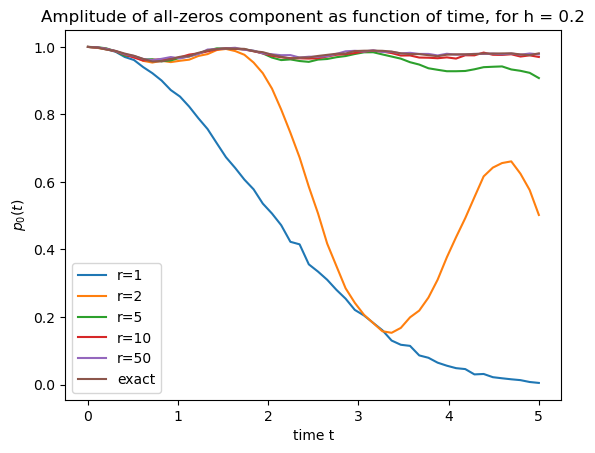

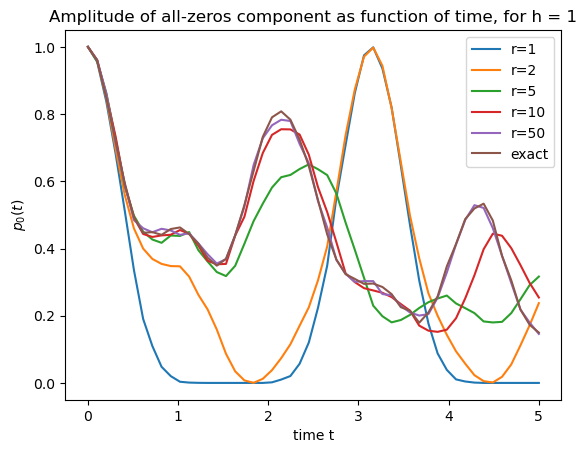

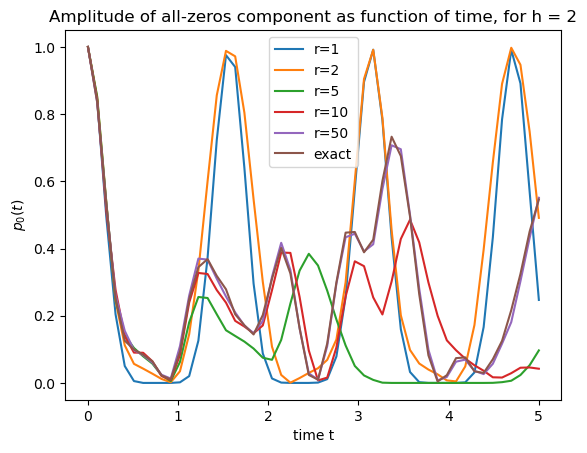

In [13]:
for h in h_values: 
    plt.title("Amplitude of all-zeros component as function of time, for h = " + str(h))
    plt.xlabel("time t")
    plt.ylabel("$p_0(t)$")
    for r in r_values:
        

        #array of p0 values as function of time t
        p0_t = []
        for tt in range(t_steps):
            dict_t = counts_results[(h,r)][tt]
            p0_t.append(get_p0(dict_t, num_shots))
        
        plt.plot(times,p0_t,label="r="+str(r))

    # import and plot exact results, don't change this! 
    with open("p0_exact_results.json", "r") as f:
        p0_exact_results = json.load(f)
    plt.plot(times, p0_exact_results[str(h)], label = "exact")
    
    plt.legend()
    plt.show()

(f) Choose an integer-valued function $r(t)$ such that $r(T)=30$ and such that, according to the theoretical Trotter error estimate, the approximation error should remain roughly constant as a function of time. For every value of $h$, plot the resulting approximation of $p_0(t)$ together with the exact solution, and interpret your results.

In [14]:
r_t = []
# We see that taking r(t) = 30/25 * t^2 = 6/5 * t^2, we get r(T) = r(5) = 30/25 * 25 = 30 as desired.
for tt in range(t_steps):
    t_s = times[tt]
    appended_r_t = max(1, int(np.ceil(6/5 * t_s**2))) # clip small values to 1
    r_t.append(appended_r_t)

counts_results_rt = {}

for h in h_values:
    counts = []
    for i in range(t_steps):
        
        qcirc_r_t = QuantumCircuit(n)
        trotterized_Ising(n, J, h, qcirc_r_t, r_t[i], times[i])
        qcirc_r_t.measure_all()
        job = backend.run(qcirc_r_t, backend=backend, shots=num_shots, optimization_level=3)
        result = job.result()
        counts_t = result.get_counts(qcirc_r_t)
            
        counts.append(counts_t)
    counts_results_rt[h] = counts


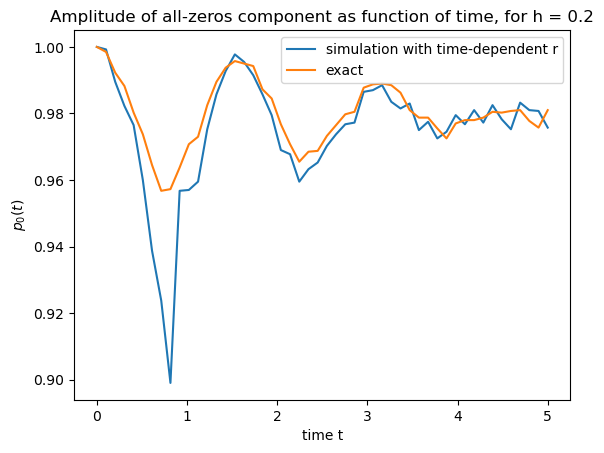

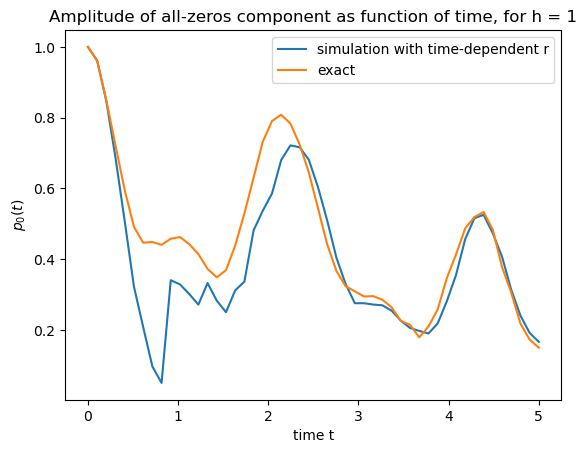

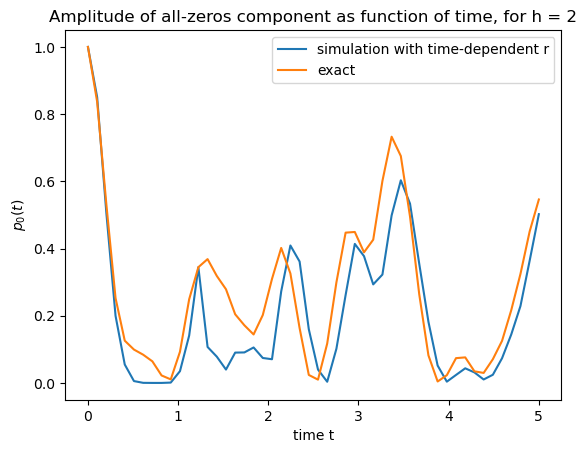

In [16]:
# Plot your results
for h in h_values: 
    plt.title("Amplitude of all-zeros component as function of time, for h = " + str(h))
    plt.xlabel("time t")
    plt.ylabel("$p_0(t)$")
   
    counts = counts_results_rt[h] 
    
    p0_t = []
    for tt in range(t_steps):
        dict_r_t = counts[tt]
        p0_t.append(get_p0(dict_r_t, num_shots))
    
    plt.plot(times,p0_t,label="simulation with time-dependent r")
    
    with open("p0_exact_results.json", "r") as f:
        p0_exact_results = json.load(f)
    plt.plot(times, p0_exact_results[str(h)], label = "exact")
    
    plt.legend()
    plt.show()

6. Implement a function M_z(counts,num_shots) that takes as input a counts dictionary (from measuring the output of a circuit num_shots times) and the corresponding number of shots num_shots and outputs the empirical expectation value of the output state $\ket{\psi}$ of the circuit from which counts was obtained. 

In [ ]:
def M_z(counts,num_shots):

    """
    Given counts dictionary of some quantum state measured in Z-basis, computes total magnetisation of the state.

    input:
    - dict counts: counts obtained from measuring quantum state

    """

    ### YOUR CODE ###
        Mz = ...
    #################

    return Mz  

7. For the same initial state and parameter regimes as in Task 3.4 (a), plot the total magnetisation $\langle M\rangle_{\psi(t)}$ of the final state $\psi(t)$ as a function of time using the function M_z from the previous exercise. 

In [ ]:
for h in h_values: 
    plt.title("Amplitude of Magnetisation as function of time, for h = " + str(h))
    plt.xlabel("time t")
    plt.ylabel("$M(t)$")
    for r in r_values:
        ### YOUR CODE ###
        
        # array of M_z values as function of time t
        mz_t = []
        
        #################
        
        plt.plot(times,mz_t,label="r="+str(r))   

    # import and plot exact results, don't change anything here
    with open("mz_exact_results.json", "r") as f:
        mz_exact_results = json.load(f)
    plt.plot(times,mz_exact_results[str(h)], label="exact")
    
    plt.legend()
    plt.show()

## Exercise 4: Hamiltonian simulation of the Transverse-Field Ising Hamiltonian in qBraid using real quantum device

1. Fix parameters $n = 4$, $J = 1$, $h=0.2$ and total evolution time $t = 2$. 
    
    For each value of $r\in \{1,2,3,4,5,10\}$, construct the Trotterized circuit approximating the evolution $\ket{\psi_t} = e^{iHt}\ket{0^n}$ and execute the circuit using both an ideal simulator and the real quantum device IQM Garnet, using \textbf{100 measurement shots} each.
    
    From the measurement outcomes, estimate the probability $p_0$ of measuring the all-zeros bitstring. Plot $p_0$ as a function of $r$ for both the simulator and the real quantum device, and interpret your results.

    _To accomplish this task you will need qBraid credits. Each group can request 600 credits using the following procedure: log in to qBraid, in the left bar go to account$\rightarrow$wallet and click ``request credits''. This will go to the teaching team and we will approve the request. However, **note that 600 credits is only about enough to run the previous circuit twice (i.e.\ twice run it for all values of $r$ indicated and with $100$ shots each time)** so make sure you test your code/circuit, using a simulator, before running it on the real device. If you need more credits, ask for more but please also justify why by sending the instructor an email._

In [ ]:
# parameters
n = 4
J = 1
h = 0.2
t = 2
num_shots = 100
r_values = [1,2,3,4,5,10]

In [ ]:
# Step 1: Get simulation results

counts_sim_results = {}

for r in r_values:
    ### YOUR CODE ###
    
    counts_sim_results[r] = ...
    #################

In [ ]:
# Step 2: Get results from real quantum device

from qbraid.runtime import QbraidProvider

# 1. Initialize the qBraid Provider
provider = QbraidProvider()

# 2. Get the Real Quantum Device
device = provider.get_device("aws:iqm:qpu:garnet")

counts_real_results = {}

for r in r_values:
   ### YOUR CODE ###
    
   counts_real_results[r] = ...
   #################

In [ ]:
# Extract p0

p0_sim = []
p0_real = []

for r in r_values:
    ### YOUR CODE ###
    p0_sim.append(...)
    p0_real.append(...)
    #################

In [ ]:
# Plot results
plt.title("Probability p0 of measuring all-zeros as function of number of Trotter steps $r$")
plt.xlabel("r")
plt.ylabel("$p0$")
plt.plot(r_values, p0_sim, label="simulation")
plt.plot(r_values, p0_real, label="real device")
plt.legend()
plt.show()